Chunk up the data by redshift & see what they prefer

In [51]:
from escripts import edata
from escripts import eMCMC
from escripts import eplots

In [2]:
files = ['/Users/eb35267/Desktop/code/home/data/Bouwens2021_fixed.txt',
               '/Users/eb35267/Desktop/code/home/data/Donnan24_GAL.txt',
             '/Users/eb35267/Desktop/code/home/data/Mcleod_24.txt']

In [4]:
data_labels = ['Bouwens+21', 'Donnan+24', 'McLeod+24']

In [5]:
dat_456 = edata.get_sorted(files, data_labels, include_zs = [4, 5, 6])

Skipping $z = 7.0
Skipping $z = 8.0
Skipping $z = 9.0
Skipping $z = 10.0
Skipping $z = 11.0
Skipping $z = 12.5
Skipping $z = 13.5
Skipping $z = 14.5


In [6]:
backend_file = '/Users/eb35267/Desktop/code/home/data/z_456.h5'

In [27]:
importlib.reload(eMCMC)

<module 'escripts.eMCMC' from '/Users/eb35267/Desktop/code/home/escripts/eMCMC.py'>

In [28]:
params = eMCMC.build_param_data({'dsigdz':{'fit':False, 'value': 0}, 'dlogedz':{'upper':0.15}})

In [30]:
UVLF_456 = eMCMC.UVLF(dat_456, params)

In [31]:
UVLF_456.run_MCMC()

  0%|                                                                                                                                                      | 0/100000 [00:00<?, ?it/s]/Users/eb35267/miniconda3/envs/research/lib/python3.12/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100000/100000 [21:21<00:00, 78.04it/s]


In [32]:
samples, best_fit, bounds, param_labels = UVLF_456.get_fit()

In [33]:
best_fit

[0.75, 0.01, -0.68, 0.46, 11.61, -0.05, -1.13, -0.08, 0.76, 0.44]

In [34]:
bounds

array([[ 0.27888317,  3.48632512],
       [-0.1354621 ,  0.08516975],
       [-0.84073003, -0.14541856],
       [-0.03674513,  1.22158567],
       [11.29757681, 14.55733196],
       [-0.10976743,  0.21386892],
       [-1.68734894, -0.23427403],
       [-0.20398505, -0.06330223],
       [ 0.50627654,  2.28897817],
       [-0.40950407,  0.60515479]])

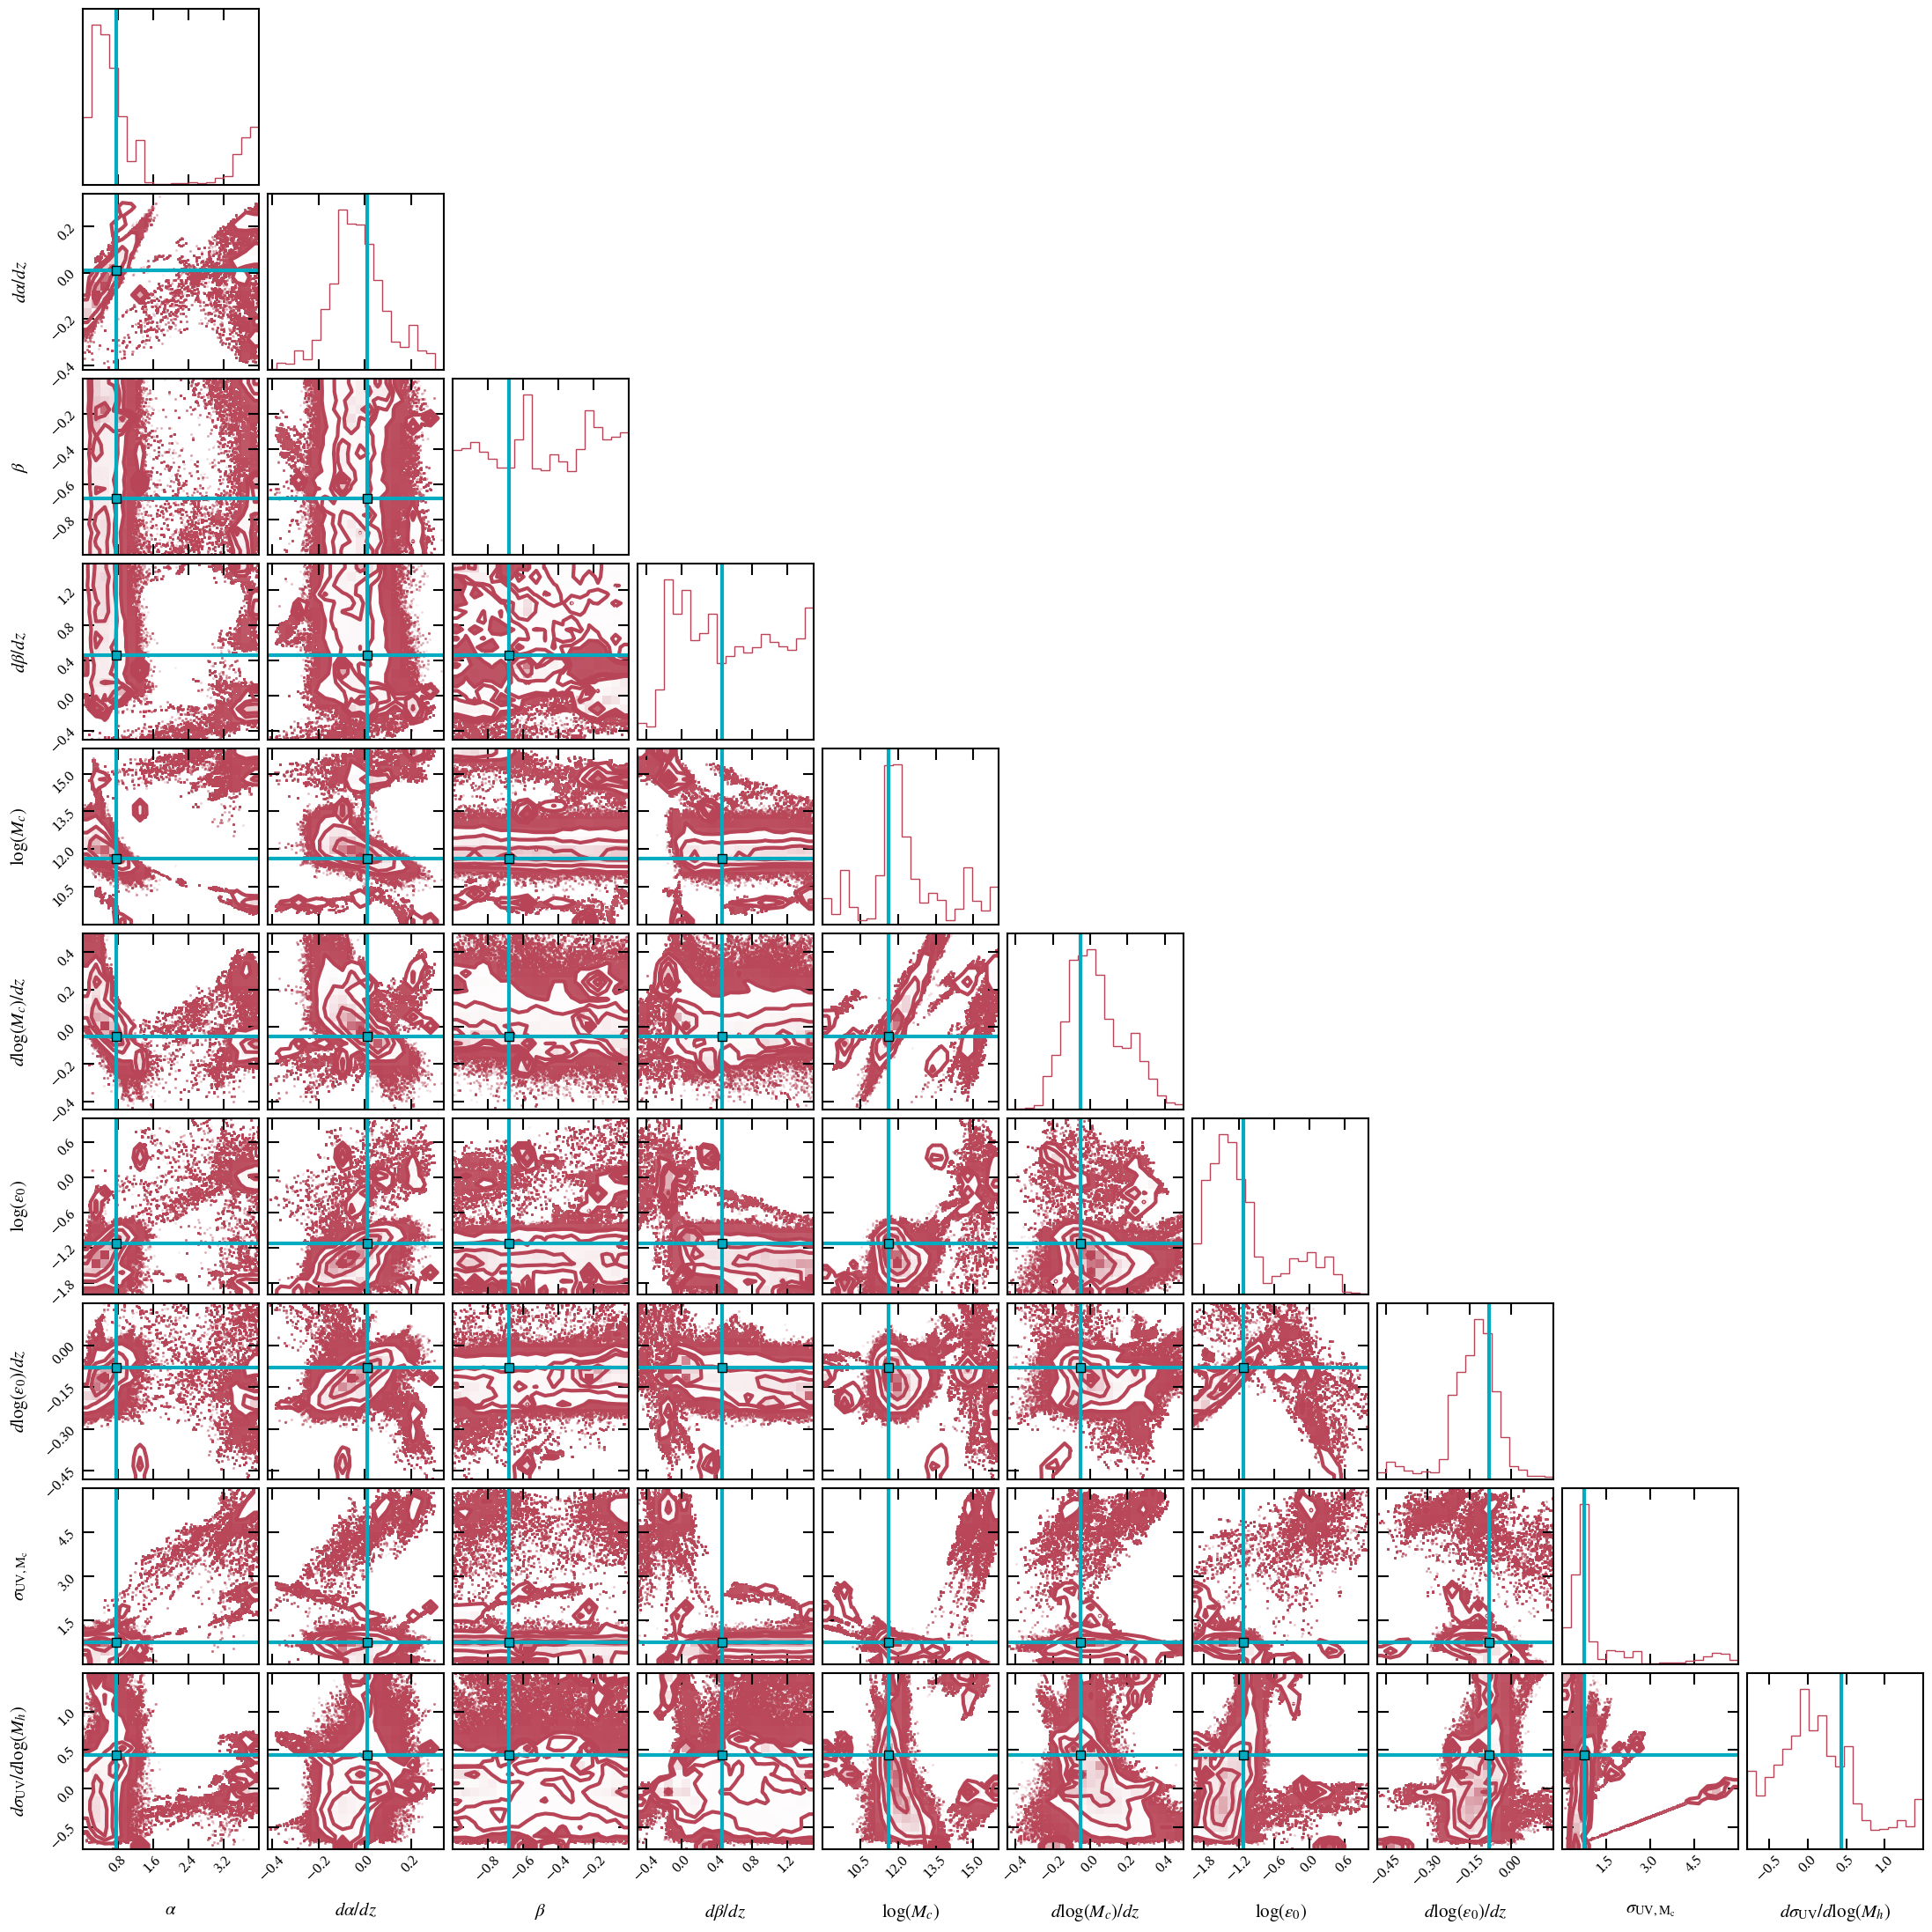

In [35]:
corner = eplots.make_corner(UVLF_456, true_vals = best_fit)

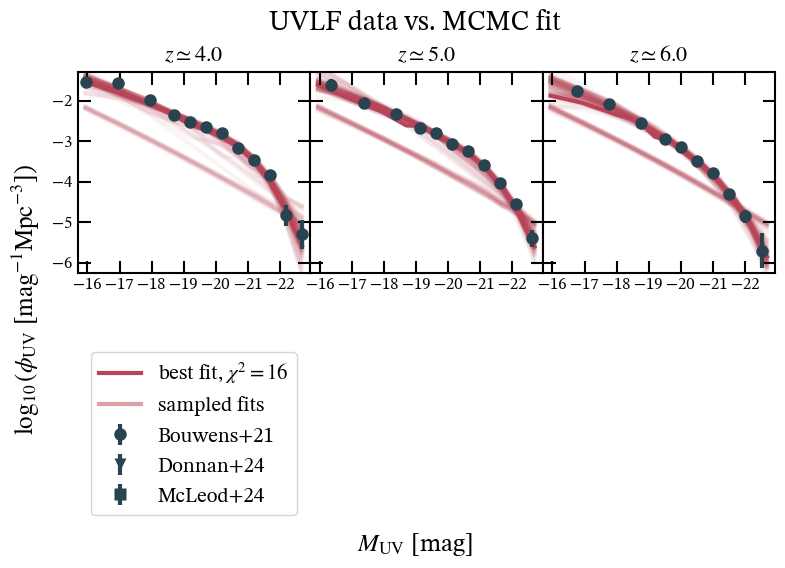

In [36]:
ev_fig = eplots.evolving_UVLF_fit(UVLF_456)

In [45]:
table = eMCMC.make_table([best_fit], param_labels, [r'$z=4,5,6$'], [bounds])

In [46]:
table

,"$z=4,5,6$"
$\alpha$,$0.75^{+2.74}_{-0.47}$
$d\alpha/dz$,$0.01^{+0.08}_{-0.15}$
$\beta$,$-0.68^{+0.53}_{-0.16}$
$d\beta/dz$,$0.46^{+0.76}_{-0.5}$
$\log(M_c)$,$11.61^{+2.95}_{-0.31}$
$d\log(M_c)/dz$,$-0.05^{+0.26}_{-0.06}$
$\log(\epsilon_0)$,$-1.13^{+0.9}_{-0.56}$
$d\log(\epsilon_0)/dz$,$-0.08^{+0.02}_{-0.12}$
"$\sigma_{\rm{UV}, M_c}$",$0.76^{+1.53}_{-0.25}$
$d\sigma_{\rm{UV}}/d\log(M_{h})$,$0.44^{+0.17}_{-0.85}$


In [50]:
dfi.export(table, 'test.png', table_conversion = 'matplotlib', use_mathjax = True)